# Import

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from matplotlib.patches import ConnectionPatch

# Extra Functions

In [35]:
def voigt_profile_single(x, A1, centre1, gamma1, sigma1, offset):
    return(A1*voigt_profile(x - centre1, sigma1, gamma1) + offset)

def voigt_model_double(x, A1, center1, gamma1, sigma1,
                       A2, delta, gamma2, sigma2, offset):

    return (
        A1 * voigt_profile(x - center1, sigma1, gamma1) +
        A2 * voigt_profile(x - (center1 + delta), sigma2, gamma2) +
        offset
    )

def lorentzian_profile(x, gamma):
    return gamma / (np.pi * (x**2 + gamma**2))

def lorentzian_single_model(x, A, center, gamma, offset):
    return A*lorentzian_profile(x- center, gamma) + offset


def lorentzian_model_double(x, A1, center1, gamma1,
                            A2, delta, gamma2, offset):

    return (
        A1 * lorentzian_profile(x - center1, gamma1) +
        A2 * lorentzian_profile(x - (center1 + delta), gamma2) +
        offset
    )

def gaussian_profile(x, sigma):
    return (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-(x**2)/(2*sigma**2))

def gaussian_single_model(x, A, center, sigma, offset):
    return A * gaussian_profile(x - center, sigma) + offset

def gaussian_model_double(x, A1, center1, sigma1,
                          A2, delta, sigma2, offset):

    return (
        A1 * gaussian_profile(x - center1, sigma1) +
        A2 * gaussian_profile(x - (center1 + delta), sigma2) +
        offset
    )



def reduced_chi_squared_calc(model, model_params, xdata, ydata, yerror):
    dof = len(xdata)-len(model_params)
    theoretical = model(xdata,*model_params)
    chi2 = np.sum((theoretical - ydata)**2/(yerror**2))
    rchi2 = chi2/dof
    return chi2, rchi2

def residual_calculator(xdata, ydata, yerr, model, model_params):
    fit = model(xdata, *model_params)
    residual = ydata - fit
    norm_residual = residual/yerr
    return  norm_residual

# Setup and calculations

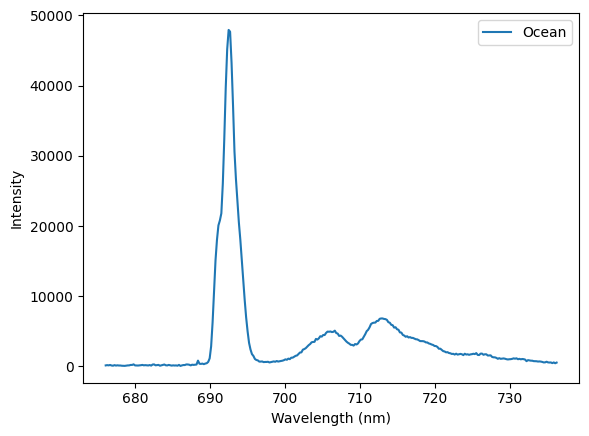

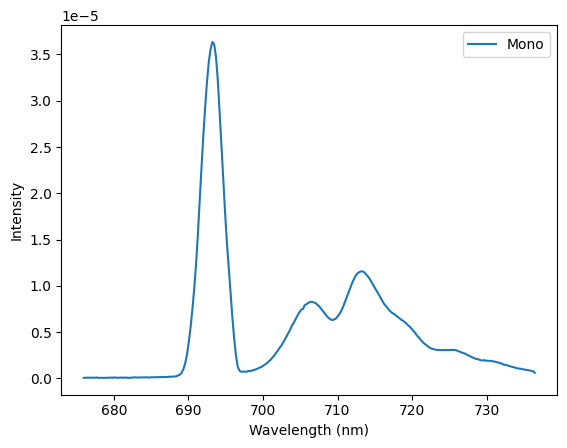

In [3]:
# Extraction

ocean_file = "Ocean_Opt_Data.xlsx"
df_ocean = pd.read_excel(ocean_file)

x_ocean = df_ocean["W_77"].to_numpy()
y_ocean = df_ocean["I_77"].to_numpy()

mono_file = "mono_77_9830_Data.csv"
df_mono = pd.read_csv(mono_file)

x_mono = df_mono["x"].to_numpy()
y_mono = df_mono["y"].to_numpy()
y_err_mono = df_mono["yerr"].to_numpy()

x_mono = np.flip(x_mono)
y_mono = np.flip(y_mono)
y_err_mono = np.flip(y_err_mono)

ind_min = np.argmin(np.abs(x_ocean - x_mono[0]))
ind_max = np.argmin(np.abs(x_ocean - x_mono[-1]))

x_ocean = x_ocean[ind_min:ind_max]
y_ocean = y_ocean[ind_min:ind_max]


plt.figure(1)
plt.plot(x_ocean, y_ocean, label="Ocean")
plt.legend()
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.show()

plt.figure(1)
plt.plot(x_mono, y_mono, label="Mono")
plt.legend()
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.show()

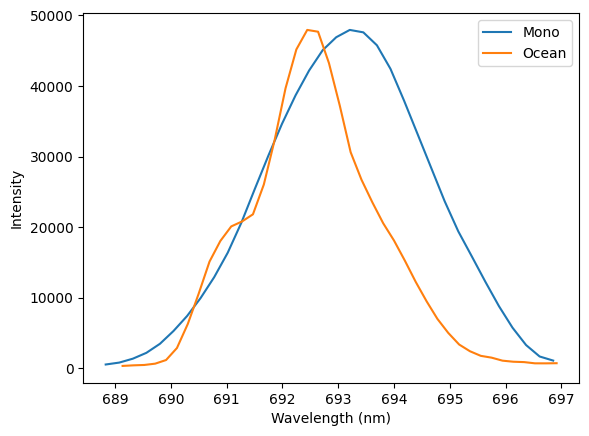

In [4]:
# masking

mask_min_ocean = 689.1
mask_max_ocean = 697

mask_min_mono = 688.7
mask_max_mono = 697

mask_ocean = (x_ocean >= mask_min_ocean) & (x_ocean <= mask_max_ocean)
mask_mono = (x_mono >= mask_min_mono) & (x_mono <= mask_max_mono)

x_ocean_masked = x_ocean[mask_ocean]
y_ocean_masked = y_ocean[mask_ocean]

x_mono_masked = x_mono[mask_mono]
y_mono_masked = y_mono[mask_mono]
y_err_mono_masked = y_err_mono[mask_mono]

normalisation_scalefactor = (np.max(y_ocean_masked)/np.max(y_mono_masked))

y_mono_masked = y_mono_masked*normalisation_scalefactor
y_err_mono_masked = y_err_mono_masked*normalisation_scalefactor

plt.figure()

plt.plot(x_mono_masked, y_mono_masked, label="Mono")
plt.plot(x_ocean_masked, y_ocean_masked, label="Ocean")
plt.legend()
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")

plt.show()

In [5]:
#fake errorbars for ocean, need to recollect this:
y_err_ocean_masked = 0.01* np.argmax(y_ocean_masked)

# Voigt Fit

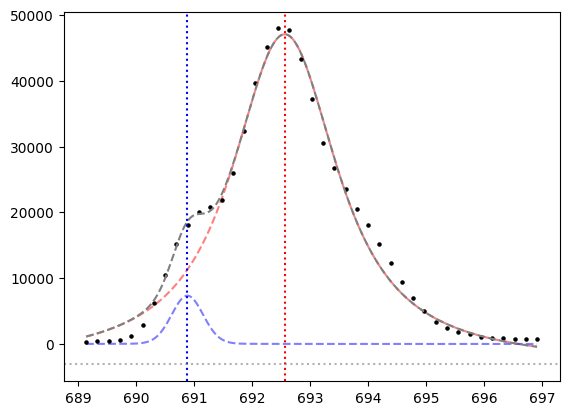

----- R1 Fit parameters -----
Amplitude: 167032.36582
Amplitude Frac: 0.97067
R1: 692.56136
R1 gamma: 1.00000
R1 sigma: 0.25757
----- R2 Fit parameters -----
Amplitude: 5046.49675
Amplitude Frac: 0.02933
R2: 690.88250
R2 gamma: 0.01000
R2 sigma: 0.26656
Reduced chi 2: 100767823.15353


In [6]:
# ocean

ocean_R1_guess = x_ocean_masked[np.argmax(y_ocean_masked)]
A1_ocean_guess = np.max(y_ocean_masked)
A2_ocean_guess = 0.4* A1_ocean_guess

p0_ocean_voigt = [A1_ocean_guess, ocean_R1_guess, 0.3, 0.3, A2_ocean_guess, -1.9, 0.3, 0.3, np.min(y_ocean_masked)]

bounds_ocean_voigt = [
    [np.max(y_ocean_masked)*0.01, 690, 0.01, 0.01, np.max(y_ocean_masked)*0.01, -3, 0.01, 0.01, -np.inf], #lower
    [4*A1_ocean_guess, 696, 1, 1, 1.6*A1_ocean_guess, -0.5, 1, 1, np.inf] #upper
]

pop_ocean_voigt, cov_ocean_voigt = curve_fit(voigt_model_double,
                                             x_ocean_masked,
                                             y_ocean_masked,
                                             sigma = y_err_ocean_masked,
                                             absolute_sigma=True,
                                             p0 = p0_ocean_voigt,
                                             bounds = bounds_ocean_voigt,
                                             maxfev = 10000)

x_fit_ocean = np.linspace(x_ocean_masked[0], x_ocean_masked[-1], 2000)

pop_R1_ocean_voigt = [pop_ocean_voigt[0],pop_ocean_voigt[1],pop_ocean_voigt[2],pop_ocean_voigt[3], pop_ocean_voigt[-1]]
pop_R2_ocean_voigt = [pop_ocean_voigt[4], pop_ocean_voigt[1]+pop_ocean_voigt[5], pop_ocean_voigt[6], pop_ocean_voigt[7], 0]

R1_ocean_voigt = voigt_profile_single(x_fit_ocean, *pop_R1_ocean_voigt)
R2_ocean_voigt = voigt_profile_single(x_fit_ocean, *pop_R2_ocean_voigt)

baseline_ocean_voigt = pop_ocean_voigt[-1]

chi2_ocean_voigt, rchi2_ocean_voigt = reduced_chi_squared_calc(voigt_model_double, pop_ocean_voigt, x_ocean_masked, y_ocean_masked, y_err_ocean_masked)

plt.figure(1)
plt.scatter(x_ocean_masked, y_ocean_masked, s = 5, color = "black")
plt.plot(x_fit_ocean, voigt_model_double(x_fit_ocean, *pop_ocean_voigt), color = "grey", linestyle = "--")

plt.plot(x_fit_ocean, R1_ocean_voigt, color = "red", linestyle = "--", alpha = 0.5, zorder = -1)
plt.plot(x_fit_ocean, R2_ocean_voigt, color = "blue", linestyle = "--", alpha = 0.5, zorder = -1)

plt.axvline(pop_R1_ocean_voigt[1], color = "red", linestyle = ":")
plt.axvline(pop_R2_ocean_voigt[1], color = "blue", linestyle = ":")
plt.axhline(baseline_ocean_voigt, color="grey", linestyle=":", alpha=0.6)

plt.show()

print(f"----- R1 Fit parameters -----")
print(f"Amplitude: {pop_R1_ocean_voigt[0]:.5f}")
print(f"Amplitude Frac: {(pop_R1_ocean_voigt[0]/(pop_R1_ocean_voigt[0]+pop_R2_ocean_voigt[0])):.5f}")
print(f"R1: {pop_R1_ocean_voigt[1]:.5f}")
print(f"R1 gamma: {pop_R1_ocean_voigt[2]:.5f}")
print(f"R1 sigma: {pop_R1_ocean_voigt[3]:.5f}")

print(f"----- R2 Fit parameters -----")
print(f"Amplitude: {pop_R2_ocean_voigt[0]:.5f}")
print(f"Amplitude Frac: {(pop_R2_ocean_voigt[0]/(pop_R1_ocean_voigt[0]+pop_R2_ocean_voigt[0])):.5f}")
print(f"R2: {pop_R2_ocean_voigt[1]:.5f}")
print(f"R2 gamma: {pop_R2_ocean_voigt[2]:.5f}")
print(f"R2 sigma: {pop_R2_ocean_voigt[3]:.5f}")

print(f"Reduced chi 2: {rchi2_ocean_voigt:.5f}")

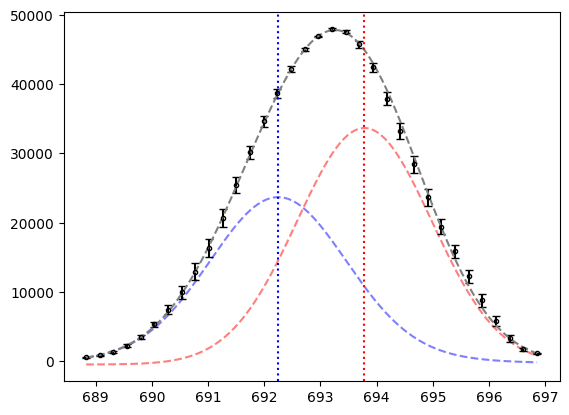

----- R1 Fit parameters -----
Amplitude: 102635.47034
Amplitude Frac: 0.56349
R1: 693.78315
----- R2 Fit parameters -----
Amplitude: 79505.93952
Amplitude Frac: 0.43651
R2: 692.24755


In [7]:
# mono

mono_R1_guess = x_mono_masked[np.argmax(y_mono_masked)]

p0_mono_voigt = [np.max(y_mono_masked) / 2, mono_R1_guess, 0.3, 0.3, np.max(y_mono_masked), -1.9, 0.3, 0.3,
                  np.min(y_mono_masked)]

bounds_mono_voigt = [
    [np.max(y_mono_masked) * 0.01, 690, 0, 0, np.max(y_mono_masked) * 0.01, -3, 0, 0, -np.inf],  #lower
    [np.inf, 696, np.inf, np.inf, np.inf, -0.5, np.inf, np.inf, np.inf]  #upper
]

pop_mono_voigt, cov_mono_voigt = curve_fit(voigt_model_double,
                                             x_mono_masked,
                                             y_mono_masked,
                                           sigma = y_err_mono_masked,
                                           absolute_sigma= True,
                                             p0=p0_mono_voigt,
                                             bounds=bounds_mono_voigt,
                                             maxfev=10000)

x_fit_mono = np.linspace(x_mono_masked[0], x_mono_masked[-1], 2000)

pop_R1_mono_voigt = [pop_mono_voigt[0], pop_mono_voigt[1], pop_mono_voigt[2], pop_mono_voigt[3],
                      pop_mono_voigt[-1]]
pop_R2_mono_voigt = [pop_mono_voigt[4], pop_mono_voigt[1] + pop_mono_voigt[5], pop_mono_voigt[6],
                      pop_mono_voigt[7], pop_mono_voigt[-1]]

R1_mono_voigt = voigt_profile_single(x_fit_mono, *pop_R1_mono_voigt)
R2_mono_voigt = voigt_profile_single(x_fit_mono, *pop_R2_mono_voigt)

plt.figure(1)
plt.errorbar(x_mono_masked, y_mono_masked, yerr=y_err_mono_masked,
             fmt = "o", linestyle = "none",
             markersize =3, color="black", capsize = 3, markerfacecolor = "none")
plt.plot(x_fit_mono, voigt_model_double(x_fit_mono, *pop_mono_voigt), color="grey", linestyle="--")

plt.plot(x_fit_mono, R1_mono_voigt, color="red", linestyle="--", alpha=0.5, zorder=-1)
plt.plot(x_fit_mono, R2_mono_voigt, color="blue", linestyle="--", alpha=0.5, zorder=-1)

plt.axvline(pop_R1_mono_voigt[1], color="red", linestyle=":")
plt.axvline(pop_R2_mono_voigt[1], color="blue", linestyle=":")

plt.show()

print(f"----- R1 Fit parameters -----")
print(f"Amplitude: {pop_R1_mono_voigt[0]:.5f}")
print(f"Amplitude Frac: {(pop_R1_mono_voigt[0] / (pop_R1_mono_voigt[0] + pop_R2_mono_voigt[0])):.5f}")
print(f"R1: {pop_R1_mono_voigt[1]:.5f}")

print(f"----- R2 Fit parameters -----")
print(f"Amplitude: {pop_R2_mono_voigt[0]:.5f}")
print(f"Amplitude Frac: {(pop_R2_mono_voigt[0] / (pop_R1_mono_voigt[0] + pop_R2_mono_voigt[0])):.5f}")
print(f"R2: {pop_R2_mono_voigt[1]:.5f}")

# Voigt Plot

In [8]:
# Prep

red_cb = "#e41a1c"
blue_cb = "#377eb8"
purple_cb = "#984ea3"

plt.rcParams.update({
    "font.size": 14,        # default text size
    "axes.titlesize": 16,   # title size
    "axes.labelsize": 15,   # axis labels
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.rcParams.update({
    "font.family": "Times New Roman",  # Use Times New Roman for all text
    "mathtext.fontset": "custom",      # Use custom font for math
    "mathtext.rm": "Times New Roman",  # Roman font in math
    "mathtext.it": "Times New Roman:italic",  # Italic font in math
    "mathtext.bf": "Times New Roman:bold",    # Bold font in math
    "text.usetex": False
})

residual_ocean_voigt = residual_calculator(x_ocean_masked, y_ocean_masked, y_err_ocean_masked, voigt_model_double, pop_ocean_voigt)
residual_mono_voigt = residual_calculator(x_mono_masked, y_mono_masked, y_err_mono_masked, voigt_model_double, pop_mono_voigt)

marker = "o"
fit_colours = [purple_cb, blue_cb, red_cb]

residual_band= Patch(
    facecolor= fit_colours[0],
    alpha=0.12,
    label=r"$\pm1\sigma$ Residuals"
)

common_voigt_legend = [
    Line2D([0], [0],
           color=fit_colours[0],
           linestyle='--',
           linewidth=1.5,
           label="Double Voigt Fit"),

    Line2D([0], [0],
           color=fit_colours[2],
           linestyle='--',
           linewidth=1.5,
           label="R1 Voigt Fit"),

    Line2D([0], [0],
           color=fit_colours[1],
           linestyle='--',
           linewidth=1.5,
           label="R2 Voigt Fit"),

    residual_band
]

def data_legend(label):
    return Line2D([0], [0],
                  marker=marker,
                  color="black",
                  markerfacecolor="none",
                  linestyle="none",
                  markersize=5,
                  label=label)

legend_elements_voigt_ocean = [data_legend("Ocean Optics Data")] + common_voigt_legend
legend_elements_voigt_mono = [data_legend("Monochromator Data")] + common_voigt_legend

angstrom_scalefactor = 10

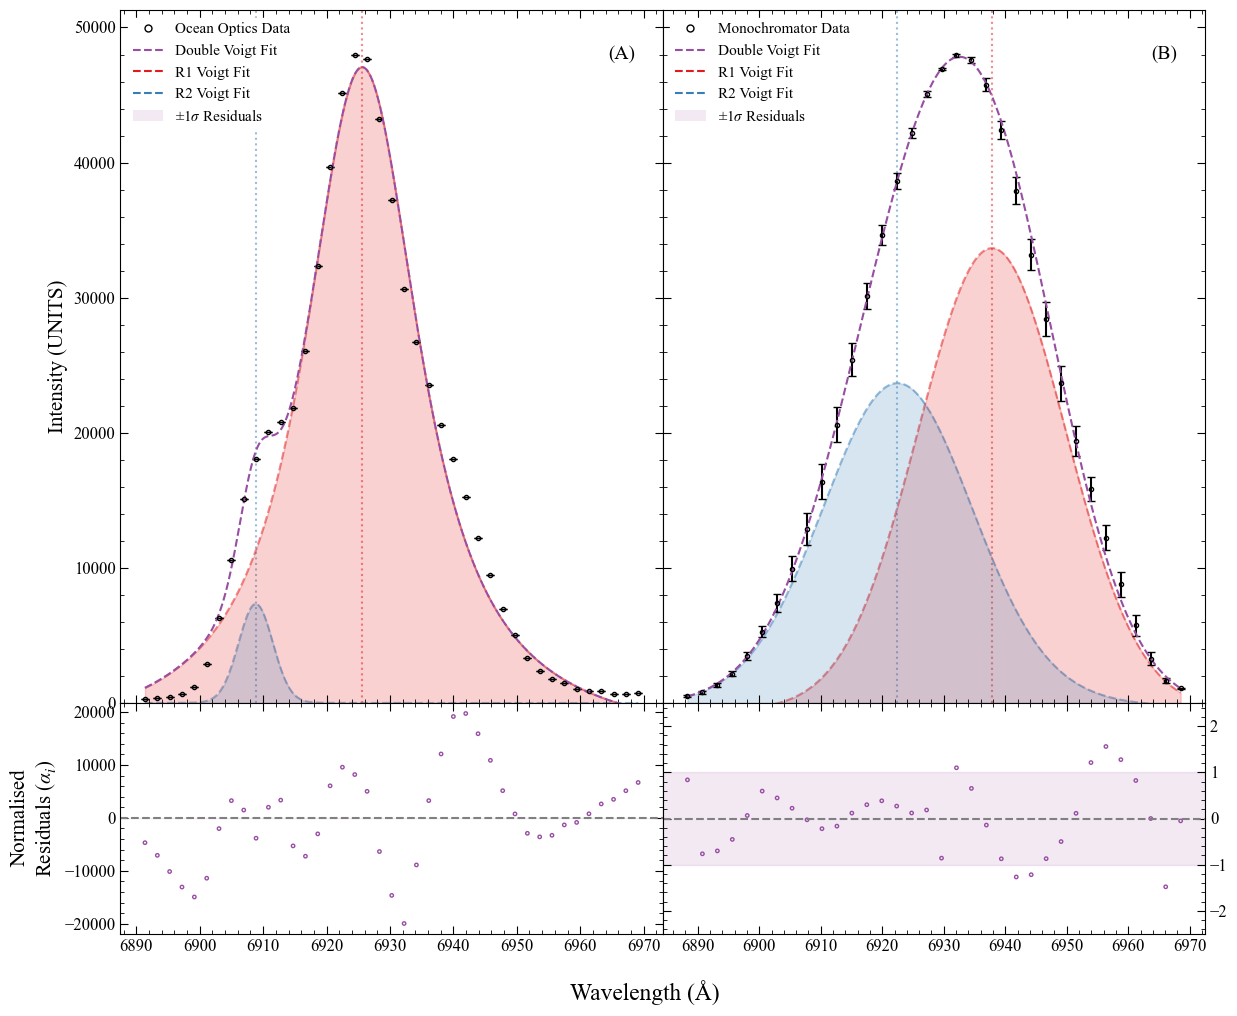

In [10]:
pc_savepath_voigt_peakshape = r"C:\Users\User\Documents\Durham Work\Year 3\Advanced_Lab\Report\Figures\voigt_peakshape.png"
laptop_savepath_voigt_peakshape = r"C:\Users\sebas\Documents\Durham Work\Year 3\Advanced Lab\Report Figures\voigt_peakshape.png"

###################
# Setup and Styling
###################
fig = plt.figure(figsize=(14,12))

gs = fig.add_gridspec(
    2,2,
    height_ratios=[3,1],
    width_ratios=[1,1],
    hspace = 0,
    wspace=0
)

ax_main_ocean = fig.add_subplot(gs[0,0])
ax_res_ocean = fig.add_subplot(gs[1,0], sharex=ax_main_ocean)

ax_main_ocean.set_ylim([0, 1.07* np.max(y_ocean_masked)])

ax_main_mono = fig.add_subplot(gs[0,1], sharey=ax_main_ocean)
ax_res_mono = fig.add_subplot(gs[1,1], sharex=ax_main_mono)


ax_res_mono.set_ylim([-2.5, 2.5])

for ax in [ax_main_ocean, ax_res_ocean, ax_main_mono, ax_res_mono]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

ax_main_mono.tick_params(labelleft=False)
ax_res_mono.tick_params(labelleft=False, labelright=True)

###########
# Main Plot
###########

for ax, xdata, x_fit, ydata, yfit, R1, R1_centre, R2, R2_centre, yerror in zip([ax_main_ocean, ax_main_mono], #ax
                                    [x_ocean_masked, x_mono_masked], #xdata
                                    [x_fit_ocean, x_fit_mono], #xfit
                                    [y_ocean_masked, y_mono_masked], #ydata
                                    [voigt_model_double(x_fit_ocean, *pop_ocean_voigt) ,voigt_model_double(x_fit_mono, *pop_mono_voigt)], #yfit
                                    [R1_ocean_voigt, R1_mono_voigt], #R1
                                    [pop_R1_ocean_voigt[1], pop_R1_mono_voigt[1]], #R1_centre
                                    [R2_ocean_voigt, R2_mono_voigt], #R2
                                    [pop_R2_ocean_voigt[1], pop_R2_mono_voigt[1]], #R2_centre
                                    [y_err_ocean_masked,y_err_mono_masked] #yerror
                                                   ):
    ax.errorbar(xdata*angstrom_scalefactor, ydata, yerr= yerror,
                color = "black", linestyle = "none", marker=marker, markersize = 3, markerfacecolor = "none", capsize =3)
    ax.plot(x_fit*angstrom_scalefactor, yfit,
            color = fit_colours[0], linestyle = "--")

    ax.plot(x_fit*angstrom_scalefactor, R1,
            color = fit_colours[2], linestyle = "--", alpha = 0.5, zorder=-1)
    ax.axvline(R1_centre*angstrom_scalefactor, color = fit_colours[2], linestyle=":", alpha = 0.5, zorder=-1)

    ax.plot(x_fit*angstrom_scalefactor, R2,
            color = fit_colours[1], linestyle = "--", alpha = 0.5, zorder=-1)
    ax.axvline(R2_centre*angstrom_scalefactor, color = fit_colours[1], linestyle=":", alpha = 0.5, zorder=-1)

    ax.fill_between(x_fit*angstrom_scalefactor, R1, pop_R1_ocean_voigt[-1],
                color=fit_colours[2], alpha=0.2)

    ax.fill_between(x_fit*angstrom_scalefactor, R2, pop_R2_ocean_voigt[-1],
                color=fit_colours[1], alpha=0.2)


ax_main_ocean.set_ylabel("Intensity (UNITS)")

ax_main_ocean.legend(
    handles = legend_elements_voigt_ocean,
    loc = "upper left",
    borderpad = 0.3,
    frameon=True,
    facecolor="white",
    edgecolor="white",
    framealpha=1.0
)
ax_main_mono.legend(
    handles = legend_elements_voigt_mono,
    loc = "upper left",
    borderpad = 0.3,
    frameon=True,
    facecolor="white",
    edgecolor="white",
    framealpha=1.0
)

ax_main_ocean.text(0.9, 0.95, "(A)", transform=ax_main_ocean.transAxes, va="top")
ax_main_mono.text(0.9, 0.95, "(B)", transform=ax_main_mono.transAxes, va="top")



################
# Residual Plots
################

for ax, xdata, residual in zip(
    [ax_res_ocean, ax_res_mono], #ax
    [x_ocean_masked, x_mono_masked], #xdata
    [residual_ocean_voigt, residual_mono_voigt] #residual
):
    ax.scatter(xdata*angstrom_scalefactor, residual,
            color = fit_colours[0], marker = marker, s = 6, facecolor = "none")
    ax.axhspan(-1, 1, color = fit_colours[0], alpha = 0.12, zorder=-1)
    ax.axhline(0, color = "grey", linestyle = "--")

ax_res_ocean.set_ylabel("Normalised\nResiduals ($\\alpha_i$)")


fig.supxlabel("Wavelength (Å)", y = 0.05)

plt.savefig(laptop_savepath_voigt_peakshape,
            dpi = 600,
            bbox_inches = "tight")
plt.show()

# Gaussian Fit

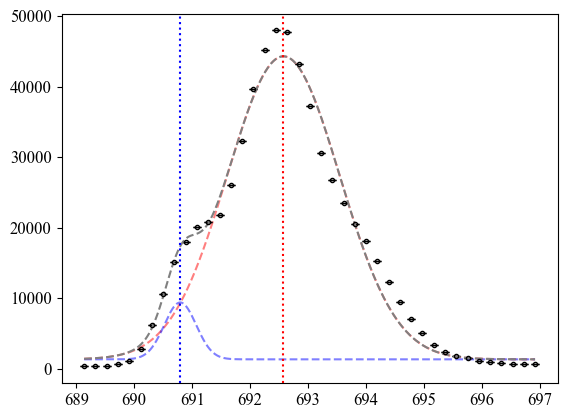

----- R1 Fit parameters -----
Amplitude: 104438.05902
Amplitude Frac: 0.94957
R1: 692.57370
----- R2 Fit parameters -----
Amplitude: 5546.78310
Amplitude Frac: 0.05043
R2: 690.79315
Rchi2: 172043924.93124


In [11]:
# Ocean

ocean_R1_guess = x_ocean_masked[np.argmax(y_ocean_masked)]

p0_ocean_gauss = [np.max(y_ocean_masked) / 2, ocean_R1_guess, 0.3, np.max(y_ocean_masked), -1.9, 0.3, np.min(y_ocean_masked)]

bounds_ocean_gauss = [
    [np.max(y_ocean_masked) * 0.01, 690, 0,  np.max(y_ocean_masked) * 0.01, -3, 0,  -np.inf],  #lower
    [np.inf, 696, np.inf,  np.inf, -0.5, np.inf,  np.inf]  #upper
]

pop_ocean_gauss, cov_ocean_gauss = curve_fit(gaussian_model_double,
                                             x_ocean_masked,
                                             y_ocean_masked,
                                           sigma = y_err_ocean_masked,
                                           absolute_sigma= True,
                                             p0=p0_ocean_gauss,
                                             bounds=bounds_ocean_gauss,
                                             maxfev=10000)

pop_R1_ocean_gauss = [pop_ocean_gauss[0], pop_ocean_gauss[1], pop_ocean_gauss[2], pop_ocean_gauss[-1]]
pop_R2_ocean_gauss = [pop_ocean_gauss[3], pop_ocean_gauss[1] + pop_ocean_gauss[4], pop_ocean_gauss[5], pop_ocean_gauss[-1]]

R1_ocean_voigt = gaussian_single_model(x_fit_ocean, *pop_R1_ocean_gauss)
R2_ocean_voigt = gaussian_single_model(x_fit_ocean, *pop_R2_ocean_gauss)

chi2_ocean_gauss,rchi2_ocean_gauss = reduced_chi_squared_calc(gaussian_model_double, pop_ocean_gauss, x_ocean_masked, y_ocean_masked, y_err_ocean_masked)

plt.figure(1)
plt.errorbar(x_ocean_masked, y_ocean_masked, yerr=y_err_ocean_masked,
             fmt = "o", linestyle = "none",
             markersize =3, color="black", capsize = 3, markerfacecolor = "none")
plt.plot(x_fit_ocean, gaussian_model_double(x_fit_ocean, *pop_ocean_gauss), color="grey", linestyle="--")

plt.plot(x_fit_ocean, R1_ocean_voigt, color="red", linestyle="--", alpha=0.5, zorder=-1)
plt.plot(x_fit_ocean, R2_ocean_voigt, color="blue", linestyle="--", alpha=0.5, zorder=-1)

plt.axvline(pop_R1_ocean_gauss[1], color="red", linestyle=":")
plt.axvline(pop_R2_ocean_gauss[1], color="blue", linestyle=":")

plt.show()

print(f"----- R1 Fit parameters -----")
print(f"Amplitude: {pop_R1_ocean_gauss[0]:.5f}")
print(f"Amplitude Frac: {(pop_R1_ocean_gauss[0] / (pop_R1_ocean_gauss[0] + pop_R2_ocean_gauss[0])):.5f}")
print(f"R1: {pop_R1_ocean_gauss[1]:.5f}")

print(f"----- R2 Fit parameters -----")
print(f"Amplitude: {pop_R2_ocean_gauss[0]:.5f}")
print(f"Amplitude Frac: {(pop_R2_ocean_gauss[0] / (pop_R1_ocean_gauss[0] + pop_R2_ocean_gauss[0])):.5f}")
print(f"R2: {pop_R2_ocean_gauss[1]:.5f}")

print(f"Rchi2: {rchi2_ocean_gauss:.5f}")

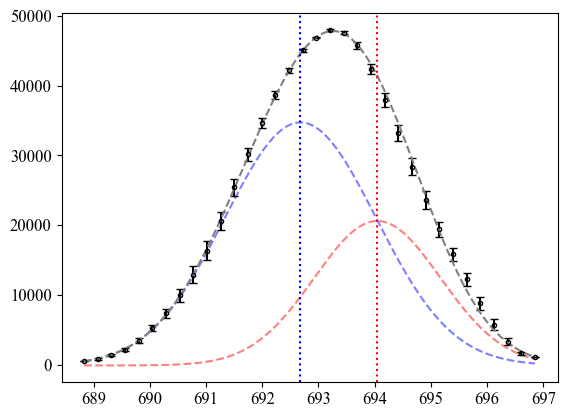

----- R1 Fit parameters -----
Amplitude: 58276.05359
Amplitude Frac: 0.33131
R1: 694.04810
----- R2 Fit parameters -----
Amplitude: 117621.15837
Amplitude Frac: 0.66869
R2: 692.68021
Rchi2: 0.74087


In [31]:
# mono

mono_R1_guess = x_mono_masked[np.argmax(y_mono_masked)]

p0_mono_gauss = [np.max(y_mono_masked) / 2, mono_R1_guess, 0.3, np.max(y_mono_masked), -1.9, 0.3, np.min(y_mono_masked)]

bounds_mono_gauss = [
    [np.max(y_mono_masked) * 0.01, 690, 0,  np.max(y_mono_masked) * 0.01, -3, 0,  -np.inf],  #lower
    [np.inf, 696, np.inf,  np.inf, -0.5, np.inf,  np.inf]  #upper
]

pop_mono_gauss, cov_mono_gauss = curve_fit(gaussian_model_double,
                                             x_mono_masked,
                                             y_mono_masked,
                                           sigma = y_err_mono_masked,
                                           absolute_sigma= True,
                                             p0=p0_mono_gauss,
                                             bounds=bounds_mono_gauss,
                                             maxfev=10000)

pop_R1_mono_gauss = [pop_mono_gauss[0], pop_mono_gauss[1], pop_mono_gauss[2], pop_mono_gauss[-1]]
pop_R2_mono_gauss = [pop_mono_gauss[3], pop_mono_gauss[1] + pop_mono_gauss[4], pop_mono_gauss[5], pop_mono_gauss[-1]]

R1_mono_gauss = gaussian_single_model(x_fit_mono, *pop_R1_mono_gauss)
R2_mono_gauss = gaussian_single_model(x_fit_mono, *pop_R2_mono_gauss)

chi2_mono_gauss,rchi2_mono_gauss = reduced_chi_squared_calc(gaussian_model_double, pop_mono_gauss, x_mono_masked, y_mono_masked, y_err_mono_masked)

plt.figure(1)
plt.errorbar(x_mono_masked, y_mono_masked, yerr=y_err_mono_masked,
             fmt = "o", linestyle = "none",
             markersize =3, color="black", capsize = 3, markerfacecolor = "none")
plt.plot(x_fit_mono, gaussian_model_double(x_fit_mono, *pop_mono_gauss), color="grey", linestyle="--")

plt.plot(x_fit_mono, R1_mono_gauss, color="red", linestyle="--", alpha=0.5, zorder=-1)
plt.plot(x_fit_mono, R2_mono_gauss, color="blue", linestyle="--", alpha=0.5, zorder=-1)

plt.axvline(pop_R1_mono_gauss[1], color="red", linestyle=":")
plt.axvline(pop_R2_mono_gauss[1], color="blue", linestyle=":")

plt.show()

print(f"----- R1 Fit parameters -----")
print(f"Amplitude: {pop_R1_mono_gauss[0]:.5f}")
print(f"Amplitude Frac: {(pop_R1_mono_gauss[0] / (pop_R1_mono_gauss[0] + pop_R2_mono_gauss[0])):.5f}")
print(f"R1: {pop_R1_mono_gauss[1]:.5f}")

print(f"----- R2 Fit parameters -----")
print(f"Amplitude: {pop_R2_mono_gauss[0]:.5f}")
print(f"Amplitude Frac: {(pop_R2_mono_gauss[0] / (pop_R1_mono_gauss[0] + pop_R2_mono_gauss[0])):.5f}")
print(f"R2: {pop_R2_mono_gauss[1]:.5f}")

print(f"Rchi2: {rchi2_mono_gauss:.5f}")

# Gaussian Plot

In [14]:
# Prep

residual_ocean_gauss = (y_ocean_masked - gaussian_model_double(x_ocean_masked, *pop_ocean_gauss))/y_err_ocean_masked
residual_mono_gauss =  (y_mono_masked - gaussian_model_double(x_mono_masked, *pop_mono_gauss))/y_err_mono_masked

residual_band = Patch(
    facecolor=fit_colours[0],
    alpha=0.12,
    label=r"$\pm1\sigma$ Residuals"
)

common_gauss_legend = [
    Line2D([0], [0],
           color=fit_colours[0],
           linestyle='--',
           linewidth=1.5,
           label="Double Gaussian Fit"),

    Line2D([0], [0],
           color=fit_colours[2],
           linestyle='--',
           linewidth=1.5,
           label="R1 Gaussian Fit"),

    Line2D([0], [0],
           color=fit_colours[1],
           linestyle='--',
           linewidth=1.5,
           label="R2 Gaussian Fit"),

    residual_band
]

legend_elements_gauss_ocean = [data_legend("Ocean Optics Data")] + common_gauss_legend
legend_elements_gauss_mono = [data_legend("Monochromator Data")] + common_gauss_legend

angstrom_scalefactor = 10
pc_savepath_gauss_peakshape = r"C:\Users\User\Documents\Durham Work\Year 3\Advanced_Lab\Report\Figures\gauss_peakshape.png"
laptop_savepath_gauss_peakshape = r"C:\Users\sebas\Documents\Durham Work\Year 3\Advanced Lab\Report Figures\gauss_peakshape.png"

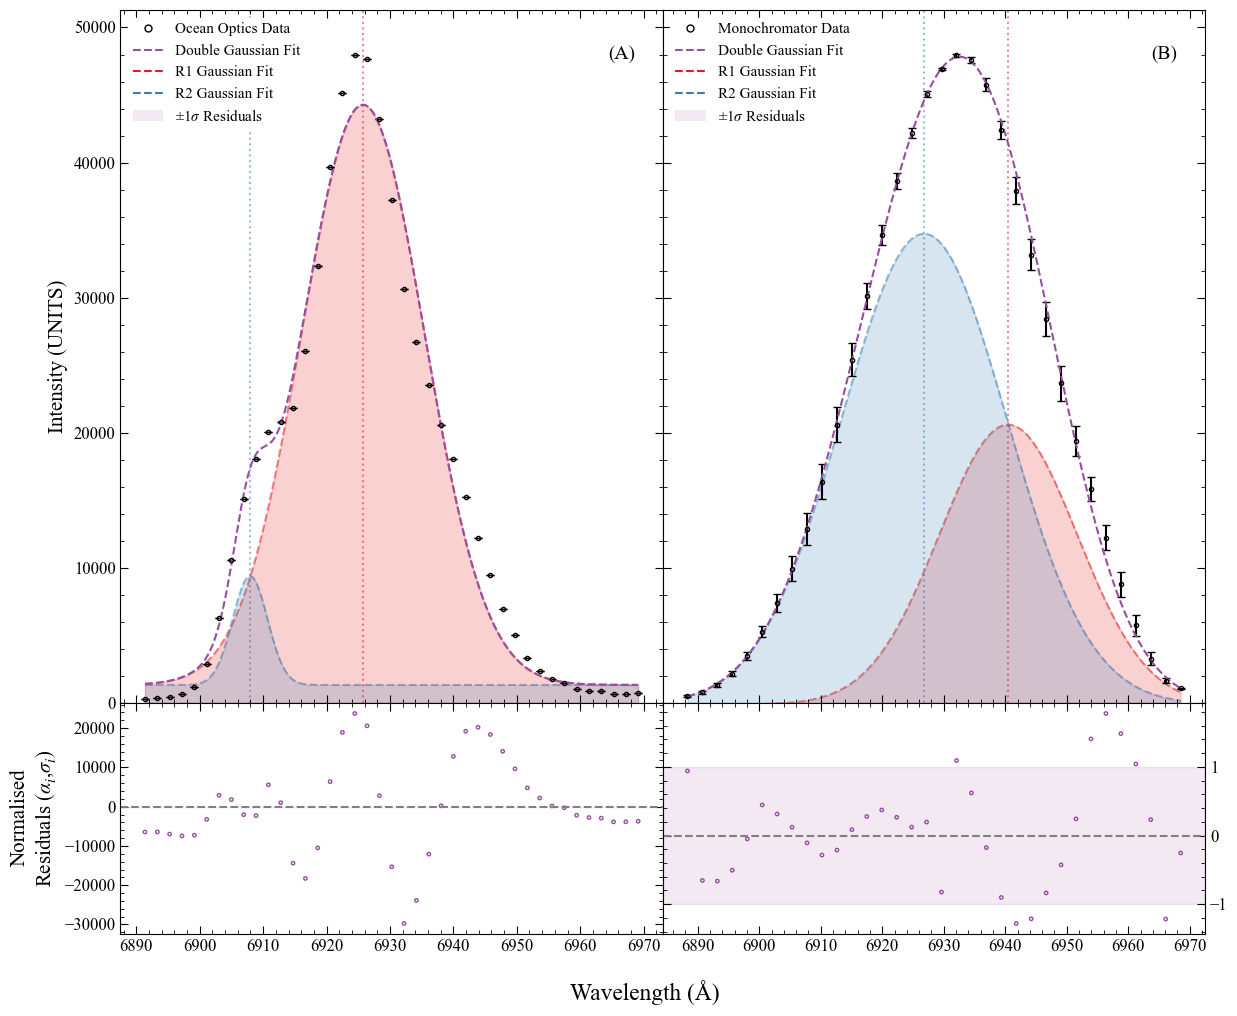

In [20]:
###################
# Setup and Styling
###################
fig = plt.figure(figsize=(14, 12))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[3, 1],
    width_ratios=[1, 1],
    hspace=0,
    wspace=0
)

ax_main_ocean = fig.add_subplot(gs[0, 0])
ax_res_ocean = fig.add_subplot(gs[1, 0], sharex=ax_main_ocean)

ax_main_ocean.set_ylim([0, 1.07 * np.max(y_ocean_masked)])

ax_main_mono = fig.add_subplot(gs[0, 1], sharey=ax_main_ocean)
ax_res_mono = fig.add_subplot(gs[1, 1], sharex=ax_main_mono)

for ax in [ax_main_ocean, ax_res_ocean, ax_main_mono, ax_res_mono]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

ax_main_mono.tick_params(labelleft=False)
ax_res_mono.tick_params(labelleft=False, labelright=True)

###########
# Main Plot
###########

for ax, xdata, x_fit, ydata, yfit, R1, R1_centre, R2, R2_centre, yerror in zip([ax_main_ocean, ax_main_mono], #ax
                                                                               [x_ocean_masked, x_mono_masked], #xdata
                                                                               [x_fit_ocean, x_fit_mono], #xfit
                                                                               [y_ocean_masked, y_mono_masked], #ydata
                                                                               [gaussian_model_double(x_fit_ocean, *pop_ocean_gauss), gaussian_model_double(x_fit_mono, *pop_mono_gauss)], #yfit
                                                                               [gaussian_single_model(x_fit_ocean, *pop_R1_ocean_gauss),gaussian_single_model(x_fit_mono, *pop_R1_mono_gauss) ], #R1
                                                                               [pop_R1_ocean_gauss[1], pop_R1_mono_gauss[1]], #R1_centre
                                                                               [gaussian_single_model(x_fit_ocean, *pop_R2_ocean_gauss),gaussian_single_model(x_fit_mono, *pop_R2_mono_gauss) ], #R2
                                                                               [pop_R2_ocean_gauss[1],pop_R2_mono_gauss[1]], #R2_centre
                                                                               [y_err_ocean_masked, y_err_mono_masked] #yerror
                                                                               ):
    ax.errorbar(xdata * angstrom_scalefactor, ydata, yerr=yerror,
                color="black", linestyle="none", marker=marker, markersize=3, markerfacecolor="none", capsize=3)
    ax.plot(x_fit * angstrom_scalefactor, yfit,
            color=fit_colours[0], linestyle="--")

    ax.plot(x_fit * angstrom_scalefactor, R1,
            color=fit_colours[2], linestyle="--", alpha=0.5, zorder=-1)
    ax.axvline(R1_centre * angstrom_scalefactor, color=fit_colours[2], linestyle=":", alpha=0.5, zorder=-1)

    ax.plot(x_fit * angstrom_scalefactor, R2,
            color=fit_colours[1], linestyle="--", alpha=0.5, zorder=-1)
    ax.axvline(R2_centre * angstrom_scalefactor, color=fit_colours[1], linestyle=":", alpha=0.5, zorder=-1)

    ax.fill_between(x_fit * angstrom_scalefactor, R1, 0,
                    color=fit_colours[2], alpha=0.2)

    ax.fill_between(x_fit * angstrom_scalefactor, R2, 0,
                    color=fit_colours[1], alpha=0.2)

ax_main_ocean.set_ylabel("Intensity (UNITS)")

ax_main_ocean.legend(
    handles=legend_elements_gauss_ocean,
    loc="upper left",
    borderpad=0.3,
    frameon=True,
    facecolor="white",
    edgecolor="white",
    framealpha=1.0
)
ax_main_mono.legend(
    handles=legend_elements_gauss_mono,
    loc="upper left",
    borderpad=0.3,
    frameon=True,
    facecolor="white",
    edgecolor="white",
    framealpha=1.0
)

ax_main_ocean.text(0.9, 0.95, "(A)", transform=ax_main_ocean.transAxes, va="top")
ax_main_mono.text(0.9, 0.95, "(B)", transform=ax_main_mono.transAxes, va="top")

################
# Residual Plots
################

for ax, xdata, residual in zip(
        [ax_res_ocean, ax_res_mono],  #ax
        [x_ocean_masked, x_mono_masked],  #xdata
        [residual_ocean_gauss, residual_mono_gauss]  #residual
):
    ax.scatter(xdata * angstrom_scalefactor, residual,
               color=fit_colours[0], marker=marker, s=6, facecolor="none")
    ax.axhspan(-1, 1, color=fit_colours[0], alpha=0.12, zorder=-1)
    ax.axhline(0, color="grey", linestyle="--")

ax_res_ocean.set_ylabel("Normalised\nResiduals ($\\alpha_i$,$\\sigma_i$)")

fig.supxlabel("Wavelength (Å)", y=0.05)

plt.savefig(laptop_savepath_gauss_peakshape,
            dpi=600,
            bbox_inches="tight")
plt.show()

# Lorentzian Fit

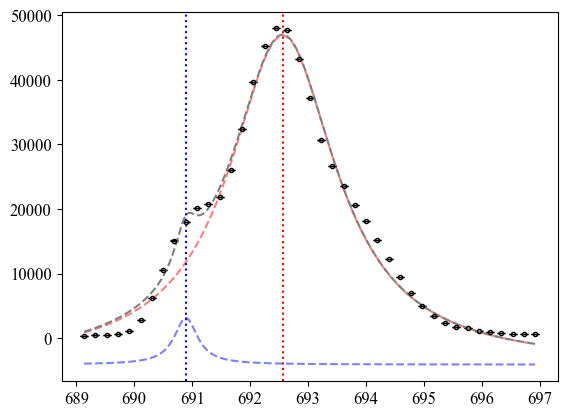

----- R1 Fit parameters -----
Amplitude: 179856.59668
Amplitude Frac: 0.97007
R1: 692.56167
----- R2 Fit parameters -----
Amplitude: 5548.51317
Amplitude Frac: 0.02993
R2: 690.89146
Rchi2: 99497251.45837


In [37]:
# Ocean
ocean_R1_guess = x_ocean_masked[np.argmax(y_ocean_masked)]

p0_ocean_lor = [np.max(y_ocean_masked) / 2, ocean_R1_guess, 0.3, np.max(y_ocean_masked), -1.9, 0.3,
                  np.min(y_ocean_masked)]

bounds_ocean_lor = [
    [np.max(y_ocean_masked) * 0.01, 690, 0, np.max(y_ocean_masked) * 0.01, -3, 0, -np.inf],  #lower
    [np.inf, 696, np.inf, np.inf, -0.5, np.inf, np.inf]  #upper
]

pop_ocean_lor, cov_ocean_lor = curve_fit(lorentzian_model_double,
                                             x_ocean_masked,
                                             y_ocean_masked,
                                             sigma=y_err_ocean_masked,
                                             absolute_sigma=True,
                                             p0=p0_ocean_lor,
                                             bounds=bounds_ocean_lor,
                                             maxfev=10000)

pop_R1_ocean_lor = [pop_ocean_lor[0], pop_ocean_lor[1], pop_ocean_lor[2], pop_ocean_lor[-1]]
pop_R2_ocean_lor = [pop_ocean_lor[3], pop_ocean_lor[1] + pop_ocean_lor[4], pop_ocean_lor[5],
                      pop_ocean_lor[-1]]

R1_ocean_lor = lorentzian_single_model(x_fit_ocean, *pop_R1_ocean_lor)
R2_ocean_lor = lorentzian_single_model(x_fit_ocean, *pop_R2_ocean_lor)

chi2_ocean_lor, rchi2_ocean_lor = reduced_chi_squared_calc(lorentzian_model_double, pop_ocean_lor, x_ocean_masked,
                                                               y_ocean_masked, y_err_ocean_masked)

plt.figure(1)
plt.errorbar(x_ocean_masked, y_ocean_masked, yerr=y_err_ocean_masked,
             fmt="o", linestyle="none",
             markersize=3, color="black", capsize=3, markerfacecolor="none")
plt.plot(x_fit_ocean, lorentzian_model_double(x_fit_ocean, *pop_ocean_lor), color="grey", linestyle="--")

plt.plot(x_fit_ocean, R1_ocean_lor, color="red", linestyle="--", alpha=0.5, zorder=-1)
plt.plot(x_fit_ocean, R2_ocean_lor, color="blue", linestyle="--", alpha=0.5, zorder=-1)

plt.axvline(pop_R1_ocean_lor[1], color="red", linestyle=":")
plt.axvline(pop_R2_ocean_lor[1], color="blue", linestyle=":")

plt.show()

print(f"----- R1 Fit parameters -----")
print(f"Amplitude: {pop_R1_ocean_lor[0]:.5f}")
print(f"Amplitude Frac: {(pop_R1_ocean_lor[0] / (pop_R1_ocean_lor[0] + pop_R2_ocean_lor[0])):.5f}")
print(f"R1: {pop_R1_ocean_lor[1]:.5f}")

print(f"----- R2 Fit parameters -----")
print(f"Amplitude: {pop_R2_ocean_lor[0]:.5f}")
print(f"Amplitude Frac: {(pop_R2_ocean_lor[0] / (pop_R1_ocean_lor[0] + pop_R2_ocean_lor[0])):.5f}")
print(f"R2: {pop_R2_ocean_lor[1]:.5f}")

print(f"Rchi2: {rchi2_ocean_lor:.5f}")

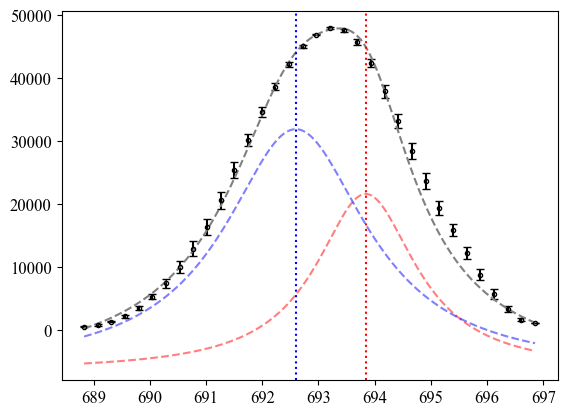

----- R1 Fit parameters -----
Amplitude: 96288.95959
Amplitude Frac: 0.34009
R1: 693.84298
----- R2 Fit parameters -----
Amplitude: 186835.67628
Amplitude Frac: 0.65991
R2: 692.59749
Rchi2: 6.96310


In [41]:
# mono
mono_R1_guess = x_mono_masked[np.argmax(y_mono_masked)]

p0_mono_lor = [np.max(y_mono_masked), mono_R1_guess, 0.3, np.max(y_mono_masked)/2, -1.9, 0.3,
                np.min(y_mono_masked)]

bounds_mono_lor = [
    [np.max(y_mono_masked) * 0.01, 690, 0, np.max(y_mono_masked) * 0.01, -3, 0, -np.inf],  #lower
    [np.inf, 696, np.inf, np.inf, -0.5, np.inf, np.inf]  #upper
]

pop_mono_lor, cov_mono_lor = curve_fit(lorentzian_model_double,
                                         x_mono_masked,
                                         y_mono_masked,
                                         sigma=y_err_mono_masked,
                                         absolute_sigma=True,
                                         p0=p0_mono_lor,
                                         bounds=bounds_mono_lor,
                                         maxfev=10000)

pop_R1_mono_lor = [pop_mono_lor[0], pop_mono_lor[1], pop_mono_lor[2], pop_mono_lor[-1]]
pop_R2_mono_lor = [pop_mono_lor[3], pop_mono_lor[1] + pop_mono_lor[4], pop_mono_lor[5],
                    pop_mono_lor[-1]]

R1_mono_lor = lorentzian_single_model(x_fit_mono, *pop_R1_mono_lor)
R2_mono_lor = lorentzian_single_model(x_fit_mono, *pop_R2_mono_lor)

chi2_mono_lor, rchi2_mono_lor = reduced_chi_squared_calc(lorentzian_model_double, pop_mono_lor, x_mono_masked,
                                                           y_mono_masked, y_err_mono_masked)

plt.figure(1)
plt.errorbar(x_mono_masked, y_mono_masked, yerr=y_err_mono_masked,
             fmt="o", linestyle="none",
             markersize=3, color="black", capsize=3, markerfacecolor="none")
plt.plot(x_fit_mono, lorentzian_model_double(x_fit_mono, *pop_mono_lor), color="grey", linestyle="--")

plt.plot(x_fit_mono, R1_mono_lor, color="red", linestyle="--", alpha=0.5, zorder=-1)
plt.plot(x_fit_mono, R2_mono_lor, color="blue", linestyle="--", alpha=0.5, zorder=-1)

plt.axvline(pop_R1_mono_lor[1], color="red", linestyle=":")
plt.axvline(pop_R2_mono_lor[1], color="blue", linestyle=":")

plt.show()

print(f"----- R1 Fit parameters -----")
print(f"Amplitude: {pop_R1_mono_lor[0]:.5f}")
print(f"Amplitude Frac: {(pop_R1_mono_lor[0] / (pop_R1_mono_lor[0] + pop_R2_mono_lor[0])):.5f}")
print(f"R1: {pop_R1_mono_lor[1]:.5f}")

print(f"----- R2 Fit parameters -----")
print(f"Amplitude: {pop_R2_mono_lor[0]:.5f}")
print(f"Amplitude Frac: {(pop_R2_mono_lor[0] / (pop_R1_mono_lor[0] + pop_R2_mono_lor[0])):.5f}")
print(f"R2: {pop_R2_mono_lor[1]:.5f}")

print(f"Rchi2: {rchi2_mono_lor:.5f}")

# Lorentzian Plot

In [42]:
# Prep

residual_ocean_lor = (y_ocean_masked - lorentzian_model_double(x_ocean_masked, *pop_ocean_lor)) / y_err_ocean_masked
residual_mono_lor = (y_mono_masked - lorentzian_model_double(x_mono_masked, *pop_mono_lor)) / y_err_mono_masked

residual_band = Patch(
    facecolor=fit_colours[0],
    alpha=0.12,
    label=r"$\pm1\sigma$ Residuals"
)

common_lor_legend = [
    Line2D([0], [0],
           color=fit_colours[0],
           linestyle='--',
           linewidth=1.5,
           label="Double Lorentzian Fit"),

    Line2D([0], [0],
           color=fit_colours[2],
           linestyle='--',
           linewidth=1.5,
           label="R1 Lorentzian Fit"),

    Line2D([0], [0],
           color=fit_colours[1],
           linestyle='--',
           linewidth=1.5,
           label="R2 Lorentzian Fit"),

    residual_band
]

legend_elements_lor_ocean = [data_legend("Ocean Optics Data")] + common_lor_legend
legend_elements_lor_mono = [data_legend("Monochromator Data")] + common_lor_legend

angstrom_scalefactor = 10
pc_savepath_lorentzian_peakshape = r"C:\Users\User\Documents\Durham Work\Year 3\Advanced_Lab\Report\Figures\lorentz_peakshape.png"
laptop_savepath_lorentzian_peakshape = r"C:\Users\sebas\Documents\Durham Work\Year 3\Advanced Lab\Report Figures\lorentz_peakshape.png"

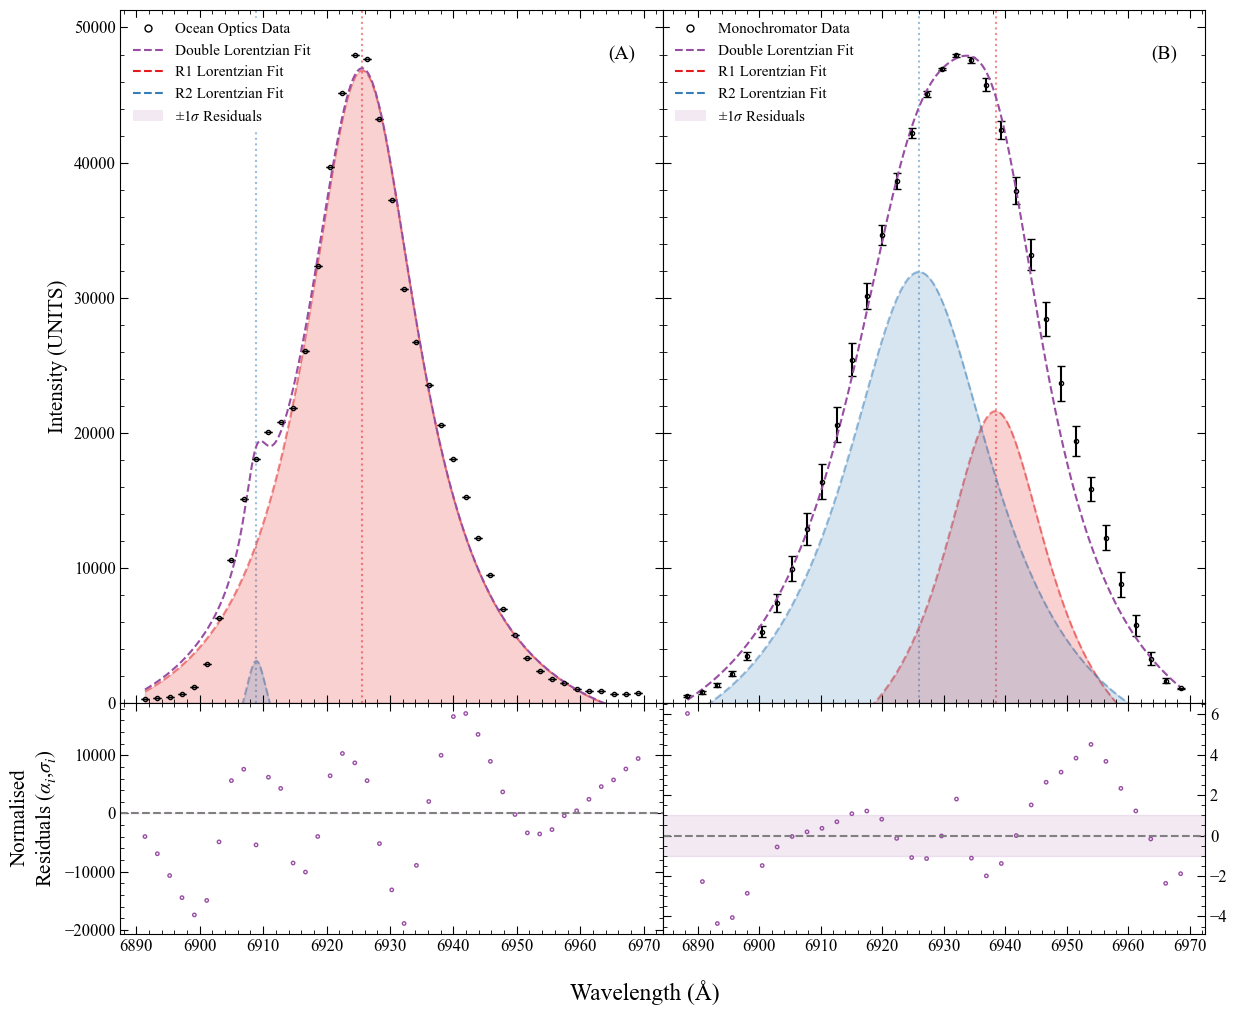

In [43]:
###################
# Setup and Styling
###################
fig = plt.figure(figsize=(14, 12))

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[3, 1],
    width_ratios=[1, 1],
    hspace=0,
    wspace=0
)

ax_main_ocean = fig.add_subplot(gs[0, 0])
ax_res_ocean = fig.add_subplot(gs[1, 0], sharex=ax_main_ocean)

ax_main_ocean.set_ylim([0, 1.07 * np.max(y_ocean_masked)])

ax_main_mono = fig.add_subplot(gs[0, 1], sharey=ax_main_ocean)
ax_res_mono = fig.add_subplot(gs[1, 1], sharex=ax_main_mono)

for ax in [ax_main_ocean, ax_res_ocean, ax_main_mono, ax_res_mono]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

ax_main_mono.tick_params(labelleft=False)
ax_res_mono.tick_params(labelleft=False, labelright=True)

###########
# Main Plot
###########

for ax, xdata, x_fit, ydata, yfit, R1, R1_centre, R2, R2_centre, yerror in zip([ax_main_ocean, ax_main_mono],  #ax
                                                                               [x_ocean_masked, x_mono_masked],  #xdata
                                                                               [x_fit_ocean, x_fit_mono],  #xfit
                                                                               [y_ocean_masked, y_mono_masked],  #ydata
                                                                               [lorentzian_model_double(x_fit_ocean,
                                                                                                      *pop_ocean_lor),
                                                                                lorentzian_model_double(x_fit_mono,
                                                                                                      *pop_mono_lor)],
                                                                               #yfit
                                                                               [lorentzian_single_model(x_fit_ocean,
                                                                                                      *pop_R1_ocean_lor),
                                                                                lorentzian_single_model(x_fit_mono,
                                                                                                      *pop_R1_mono_lor)],
                                                                               #R1
                                                                               [pop_R1_ocean_lor[1],
                                                                                pop_R1_mono_lor[1]],  #R1_centre
                                                                               [lorentzian_single_model(x_fit_ocean,
                                                                                                      *pop_R2_ocean_lor),
                                                                                lorentzian_single_model(x_fit_mono,
                                                                                                      *pop_R2_mono_lor)],
                                                                               #R2
                                                                               [pop_R2_ocean_lor[1],
                                                                                pop_R2_mono_lor[1]],  #R2_centre
                                                                               [y_err_ocean_masked, y_err_mono_masked]
                                                                               #yerror
                                                                               ):
    ax.errorbar(xdata * angstrom_scalefactor, ydata, yerr=yerror,
                color="black", linestyle="none", marker=marker, markersize=3, markerfacecolor="none", capsize=3)
    ax.plot(x_fit * angstrom_scalefactor, yfit,
            color=fit_colours[0], linestyle="--")

    ax.plot(x_fit * angstrom_scalefactor, R1,
            color=fit_colours[2], linestyle="--", alpha=0.5, zorder=-1)
    ax.axvline(R1_centre * angstrom_scalefactor, color=fit_colours[2], linestyle=":", alpha=0.5, zorder=-1)

    ax.plot(x_fit * angstrom_scalefactor, R2,
            color=fit_colours[1], linestyle="--", alpha=0.5, zorder=-1)
    ax.axvline(R2_centre * angstrom_scalefactor, color=fit_colours[1], linestyle=":", alpha=0.5, zorder=-1)

    ax.fill_between(x_fit * angstrom_scalefactor, R1, 0,
                    color=fit_colours[2], alpha=0.2)

    ax.fill_between(x_fit * angstrom_scalefactor, R2, 0,
                    color=fit_colours[1], alpha=0.2)

ax_main_ocean.set_ylabel("Intensity (UNITS)")

ax_main_ocean.legend(
    handles=legend_elements_lor_ocean,
    loc="upper left",
    borderpad=0.3,
    frameon=True,
    facecolor="white",
    edgecolor="white",
    framealpha=1.0
)
ax_main_mono.legend(
    handles=legend_elements_lor_mono,
    loc="upper left",
    borderpad=0.3,
    frameon=True,
    facecolor="white",
    edgecolor="white",
    framealpha=1.0
)

ax_main_ocean.text(0.9, 0.95, "(A)", transform=ax_main_ocean.transAxes, va="top")
ax_main_mono.text(0.9, 0.95, "(B)", transform=ax_main_mono.transAxes, va="top")

################
# Residual Plots
################

for ax, xdata, residual in zip(
        [ax_res_ocean, ax_res_mono],  #ax
        [x_ocean_masked, x_mono_masked],  #xdata
        [residual_ocean_lor, residual_mono_lor]  #residual
):
    ax.scatter(xdata * angstrom_scalefactor, residual,
               color=fit_colours[0], marker=marker, s=6, facecolor="none")
    ax.axhspan(-1, 1, color=fit_colours[0], alpha=0.12, zorder=-1)
    ax.axhline(0, color="grey", linestyle="--")

ax_res_ocean.set_ylabel("Normalised\nResiduals ($\\alpha_i$,$\\sigma_i$)")

fig.supxlabel("Wavelength (Å)", y=0.05)

plt.savefig(laptop_savepath_lorentzian_peakshape,
            dpi=600,
            bbox_inches="tight")
plt.show()

# Fit Hypothesis Testing

In [46]:
#Computing the reduced chi squared

# Voigt
chi2_ocean_voigt, rchi2_ocean_voigt = reduced_chi_squared_calc(voigt_model_double, pop_ocean_voigt, x_ocean_masked, y_ocean_masked, y_err_ocean_masked)
chi2_mono_voigt, rchi2_mono_voigt = reduced_chi_squared_calc(voigt_model_double, pop_mono_voigt, x_mono_masked, y_mono_masked, y_err_mono_masked)

# Gaussian

chi2_ocean_gauss, rchi2_ocean_gauss = reduced_chi_squared_calc(gaussian_model_double, pop_ocean_gauss, x_ocean_masked, y_ocean_masked, y_err_ocean_masked)
chi2_mono_gauss, rchi2_mono_gauss = reduced_chi_squared_calc(gaussian_model_double, pop_mono_gauss, x_mono_masked, y_mono_masked, y_err_mono_masked)

# Lorentzian
chi2_ocean_lor, rchi2_ocean_lor = reduced_chi_squared_calc(lorentzian_model_double, pop_ocean_lor, x_ocean_masked, y_ocean_masked, y_err_ocean_masked)
chi2_mono_lor, rchi2_mono_lor = reduced_chi_squared_calc(lorentzian_model_double, pop_mono_lor, x_mono_masked, y_mono_masked, y_err_mono_masked)

print(f"------- Vogit Reduced Chi Squared -------")
print(f"Ocean voigt rchi2: {rchi2_ocean_voigt:.5f}")
print(f"Mono voigt rchi2: {rchi2_mono_voigt:.5f}")

print(f"------- Gaussian Reduced Chi Squared -------")
print(f"Ocean gauss rchi2: {rchi2_ocean_gauss:.5f}")
print(f"Mono gauss rchi2: {rchi2_mono_gauss:.5f}")

print(f"------- Lorentzian Reduced Chi Squared -------")
print(f"Ocean lor rchi2: {rchi2_ocean_lor:.5f}")
print(f"Mono lor rchi2: {rchi2_mono_lor:.5f}")

print(f"------- Ratio Reduced Chi Squared -------")
print(f"Ocean ratio (gauss/voigt): {(rchi2_ocean_gauss/rchi2_ocean_voigt):.5f}")
print(f"Ocean ratio (lor/voigt): {(rchi2_ocean_lor/rchi2_ocean_voigt):.5f}")
print(f"Mono ratio (gauss/voigt): {(rchi2_mono_gauss/rchi2_mono_voigt):.5f}")
print(f"Mono ratio (lor/voigt): {(rchi2_mono_lor/rchi2_mono_voigt):.5f}")

------- Vogit Reduced Chi Squared -------
Ocean voigt rchi2: 100767823.15353
Mono voigt rchi2: 0.74629
------- Gaussian Reduced Chi Squared -------
Ocean gauss rchi2: 172043924.93124
Mono gauss rchi2: 0.74087
------- Lorentzian Reduced Chi Squared -------
Ocean lor rchi2: 99497251.45837
Mono lor rchi2: 6.96310
------- Ratio Reduced Chi Squared -------
Ocean ratio (gauss/voigt): 1.70733
Ocean ratio (lor/voigt): 0.98739
Mono ratio (gauss/voigt): 0.99274
Mono ratio (lor/voigt): 9.33027


In [49]:
####
#AIC
####
def Corr_AIC(chi2, k, N):
    AIC = chi2 + 2*k
    C_AIC = AIC + 2*k*(k+1)/(N-k-1)
    return C_AIC

def akaike_weights(AIC_values):

    AIC_values = np.array(AIC_values)

    delta = AIC_values - np.min(AIC_values)

    weights = np.exp(-0.5 * delta)

    weights /= np.sum(weights)

    return delta, weights


AIC_ocean_voigt = Corr_AIC(chi2_ocean_voigt, len(pop_ocean_voigt), len(y_ocean_masked))
AIC_mono_voigt = Corr_AIC(chi2_mono_voigt, len(pop_mono_voigt), len(y_mono_masked))

AIC_ocean_gauss = Corr_AIC(chi2_ocean_gauss, len(pop_ocean_gauss), len(y_ocean_masked))
AIC_mono_gauss = Corr_AIC(chi2_mono_gauss, len(pop_mono_gauss), len(y_mono_masked))

AIC_ocean_lor = Corr_AIC(chi2_ocean_lor, len(pop_ocean_lor), len(y_ocean_masked))
AIC_mono_lor = Corr_AIC(chi2_mono_lor, len(pop_mono_lor), len(y_mono_masked))

AIC_ocean = akaike_weights([AIC_ocean_voigt, AIC_ocean_gauss, AIC_ocean_lor])
AIC_mono = akaike_weights([AIC_mono_voigt, AIC_mono_gauss, AIC_mono_lor])


print(f"----- Check AIC Criteria ------")
print(f"Ocean: {(len(y_ocean_masked)/len(pop_ocean_voigt)):.5f}")
print(f"Mono: {(len(y_mono_masked)/len(pop_mono_voigt)):.5f}")

print(f"------ AIC ------")
print(f"AIC_ocean_voigt: {AIC_ocean_voigt:.5f}")
print(f"AIC_mono_voigt: {AIC_mono_voigt:.5f}")

print(f"AIC_ocean_gauss: {AIC_ocean_gauss:.5f}")
print(f"AIC_mono_gauss: {AIC_mono_gauss:.5f}")

print(f"AIC_ocean_lor: {AIC_ocean_lor:.5f}")
print(f"AIC_mono_lor: {AIC_mono_lor:.5f}")

print(f"------ AIC Weights -----")
print(f"Ocean: {AIC_ocean}")
print(f"Mono: {AIC_mono}")

----- Check AIC Criteria ------
Ocean: 4.55556
Mono: 3.77778
------ AIC ------
AIC_ocean_voigt: 3224570364.71937
AIC_mono_voigt: 44.15728
AIC_ocean_gauss: 5849493465.05606
AIC_mono_gauss: 38.31122
AIC_ocean_lor: 3382906566.97839
AIC_mono_lor: 206.31144
------ AIC Weights -----
Ocean: (array([0.00000000e+00, 2.62492310e+09, 1.58336202e+08]), array([1., 0., 0.]))
Mono: (array([  5.84605997,   0.        , 168.00021788]), array([5.10267800e-02, 9.48973220e-01, 3.13667963e-37]))


In [51]:
####
#BIC
####
def BIC_weights(BIC_values):
    BIC_values = np.array(BIC_values)
    delta = BIC_values - np.min(BIC_values)
    probs = np.exp(-0.5 * delta)
    probs /= np.sum(probs)
    return delta, probs

BIC_ocean_voigt = chi2_ocean_voigt + len(pop_ocean_voigt)*np.log(len(y_ocean_masked))
BIC_mono_voigt = chi2_mono_voigt + len(pop_mono_voigt)*np.log(len(y_mono_masked))

BIC_ocean_gauss = chi2_ocean_gauss + len(pop_ocean_gauss)*np.log(len(y_ocean_masked))
BIC_mono_gauss = chi2_mono_gauss + len(pop_mono_gauss)*np.log(len(y_mono_masked))

BIC_ocean_lor = chi2_ocean_lor + len(pop_ocean_lor)*np.log(len(y_ocean_masked))
BIC_mono_lor = chi2_mono_lor + len(pop_mono_lor)*np.log(len(y_mono_masked))

print(f"---- BIC Check -----")
print(f"Ocean: {len(y_ocean_masked)}")
print(f"Mono: {len(y_mono_masked)}")

print(f"----- BIC -----")
print(f"BIC_ocean_voigt: {BIC_ocean_voigt:.5f}")
print(f"BIC_mono_voigt: {BIC_mono_voigt:.5f}")
print(f"BIC_ocean_gauss: {BIC_ocean_gauss:.5f}")
print(f"BIC_mono_gauss: {BIC_mono_gauss:.5f}")
print(f"BIC_ocean_lor: {BIC_ocean_lor:.5f}")
print(f"BIC_mono_lor: {BIC_mono_lor:.5f}")

print(f"------ BIC Weights ------")
print(f"Ocean: {BIC_weights([BIC_ocean_voigt, BIC_ocean_gauss, BIC_ocean_lor])}")
print(f"Mono: {BIC_weights([BIC_mono_voigt, BIC_mono_gauss, BIC_mono_lor])}")

---- BIC Check -----
Ocean: 41
Mono: 34
----- BIC -----
BIC_ocean_voigt: 3224570374.33507
BIC_mono_voigt: 50.39453
BIC_ocean_gauss: 5849493473.65713
BIC_mono_gauss: 44.68806
BIC_ocean_lor: 3382906575.57945
BIC_mono_lor: 212.68827
------ BIC Weights ------
Ocean: (array([0.00000000e+00, 2.62492310e+09, 1.58336201e+08]), array([1., 0., 0.]))
Mono: (array([  5.70647333,   0.        , 168.00021788]), array([5.45142508e-02, 9.45485749e-01, 3.12515235e-37]))


# Fit Residual Testing

In [24]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox, acorr_breusch_godfrey
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf

In [52]:
# Durbin Watson

dw_ocean_voigt = durbin_watson(residual_ocean_voigt)
dw_mono_voigt = durbin_watson(residual_mono_voigt)

dw_ocean_gauss = durbin_watson(residual_ocean_gauss)
dw_mono_gauss = durbin_watson(residual_mono_gauss)

dw_ocean_lor = durbin_watson(residual_ocean_lor)
dw_mono_lor = durbin_watson(residual_mono_lor)

print("---- Voigt ----")
print(f"Ocean: {dw_ocean_voigt}")
print(f"Mono: {dw_mono_voigt}")
print("---- Gauss ----")
print(f"Ocean: {dw_ocean_gauss}")
print(f"Mono: {dw_mono_gauss}")
print("---- Lorentz ----")
print(f"Ocean: {dw_ocean_lor}")
print(f"Mono: {dw_mono_lor}")

---- Voigt ----
Ocean: 0.3637507585523311
Mono: 0.9153938054787472
---- Gauss ----
Ocean: 0.41054884412060716
Mono: 0.7903616413335848
---- Lorentz ----
Ocean: 0.4624195580903034
Mono: 0.5946527942281475


In [54]:
# Ljung-Box

lb_results_ocean_voigt = acorr_ljungbox(residual_ocean_voigt, lags = [5], return_df = True)
lb_results_mono_voigt = acorr_ljungbox(residual_mono_voigt, lags = [5], return_df = True)
lb_results_ocean_gauss = acorr_ljungbox(residual_ocean_gauss, lags = [5], return_df = True)
lb_results_mono_gauss = acorr_ljungbox(residual_mono_gauss, lags = [5], return_df = True)
lb_results_ocean_lor = acorr_ljungbox(residual_ocean_lor, lags = [5], return_df = True)
lb_results_mono_lor = acorr_ljungbox(residual_mono_lor, lags = [5], return_df = True)

print("---- Voigt ----")
print(f"Ocean: {lb_results_ocean_voigt}")
print(f"Mono: {lb_results_mono_voigt}")
print("---- Gauss ----")
print(f"Ocean: {lb_results_ocean_gauss}")
print(f"Mono: {lb_results_mono_gauss}")
print("---- Lorentz ----")
print(f"Ocean: {lb_results_ocean_lor}")
print(f"Mono: {lb_results_mono_lor}")

---- Voigt ----
Ocean:      lb_stat     lb_pvalue
5  47.953286  3.630771e-09
Mono:      lb_stat  lb_pvalue
5  26.943877   0.000058
---- Gauss ----
Ocean:      lb_stat     lb_pvalue
5  61.487183  5.987366e-12
Mono:      lb_stat  lb_pvalue
5  29.391461   0.000019
---- Lorentz ----
Ocean:      lb_stat     lb_pvalue
5  43.037596  3.630806e-08
Mono:      lb_stat  lb_pvalue
5  17.258214   0.004035


# Autocorrelation Plots

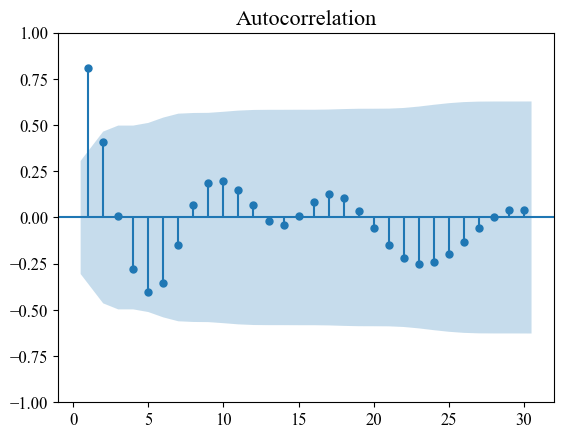

In [27]:
plot_acf(residual_ocean_voigt, lags=30, zero=False)
plt.show()

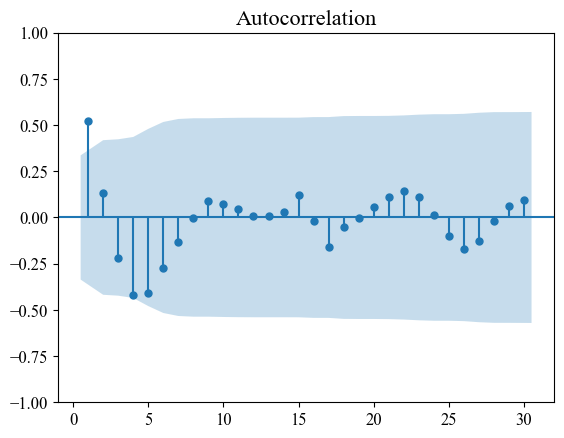

In [28]:
plot_acf(residual_mono_voigt, lags=30, zero=False)
plt.show()

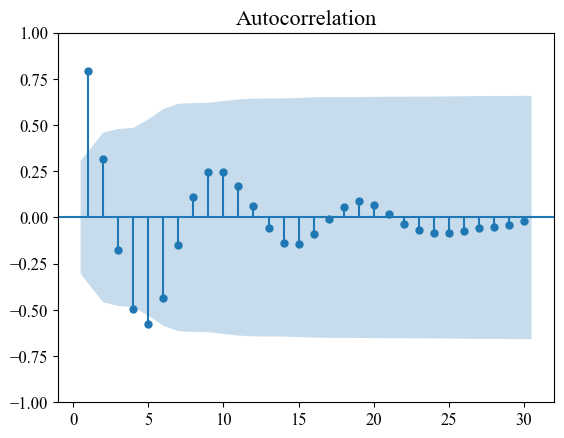

In [29]:
plot_acf(residual_ocean_gauss, lags=30, zero=False)
plt.show()

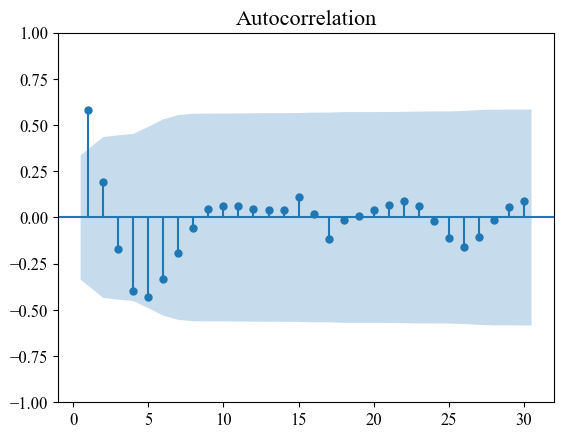

In [30]:
plot_acf(residual_mono_gauss, lags=30, zero=False)
plt.show()

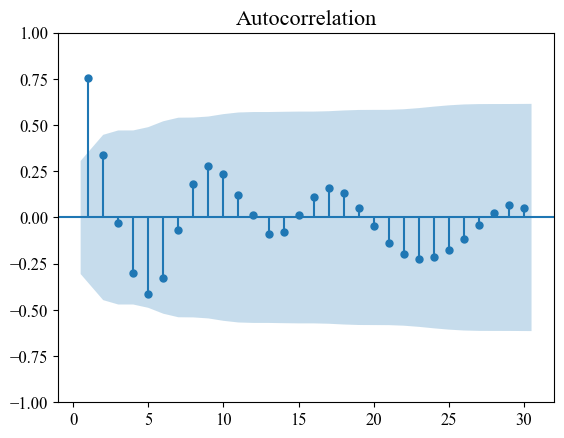

In [55]:
plot_acf(residual_ocean_lor, lags=30, zero=False)
plt.show()

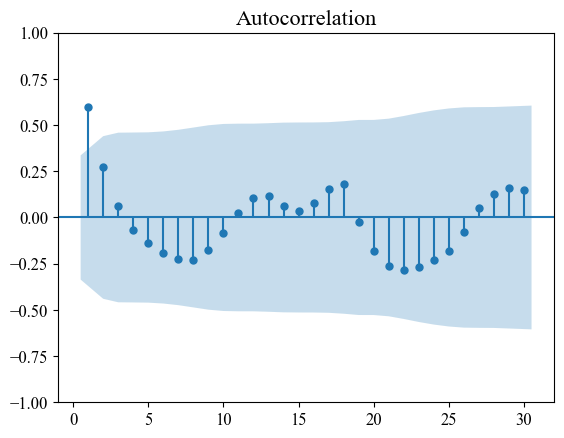

In [56]:
plot_acf(residual_mono_lor, lags=30, zero=False)
plt.show()